In [1]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [2]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","TRINITI","SIGLO"]
Nsets = len(datasets)

In [3]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Elastic momentum

Mielewska, B., Linert, I., King, G. C., & Zubek, M. (2004). Differential cross sections for elastic electron scattering in argon over the angular range 130°-180°. Physical Review A - Atomic, Molecular, and Optical Physics, 69(6), 1–8. https://doi.org/10.1103/PhysRevA.69.062716
True
Panajotovic, R., et al. "Critical minima in elastic electron scattering by argon." Journal of Physics B: Atomic, Molecular and Optical Physics 30.24 (1997): 5877.
True
Gibson, J. C., Gulley, R. J., Sullivan, J. P., Buckman, S. J., Chan, V., & Burrow, P. D. (1996). Elastic electron scattering from argon at low incident energies. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(14), 3177–3195. https://doi.org/10.1088/0953-4075/29/14/025
True
Srivastava, S. K., Tanaka, H., Chutjian, A., & Trajmar, S. (1981). Elastic scattering of intermediate-energy electrons by Ar and Kr. Physical Review A, 23(5).
True


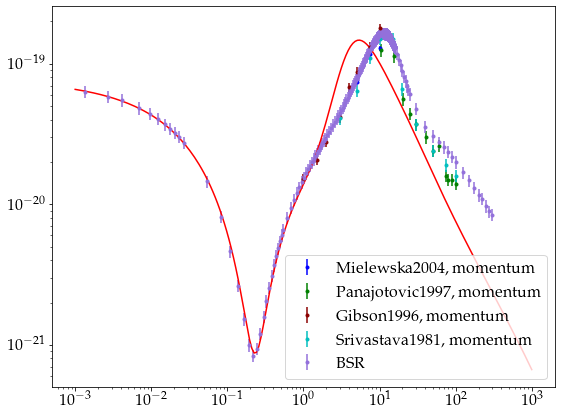

In [4]:
from models import *
dataType = crs.typeDictS2I['Elastic, momentum']


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]+', momentum']
        print(swarm.ref)
        print(swarm.datasets[dataType].error_provided)
        temp = np.copy(swarm.datasets[dataType].data)
#         mask = temp[:,0] <= 1.0
#         temp = np.copy(temp[mask,:])
        W += [temp]
    
        filename = '%s.momentum.txt' % (refs[k])
        np.savetxt(filename, temp)
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==0)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
#         mask = temp[:,0] <= 1.0
#         temp = np.copy(temp[mask,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
#         print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

        filename = '%s.momentum.txt' % ('BSR')
        np.savetxt(filename, temp)
    
# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([-1.488, 65.4, -84.3, 0.883])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest
model0 = elastic_MERT(theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

filename = 'Elastic.MERT.txt'
temp = np.array([Etest, model0]).T
np.savetxt(filename, temp)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,model0,'-r')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./elastic.pdf", dpi=600)
# plt.savefig('./elastic.png',dpi=1200)


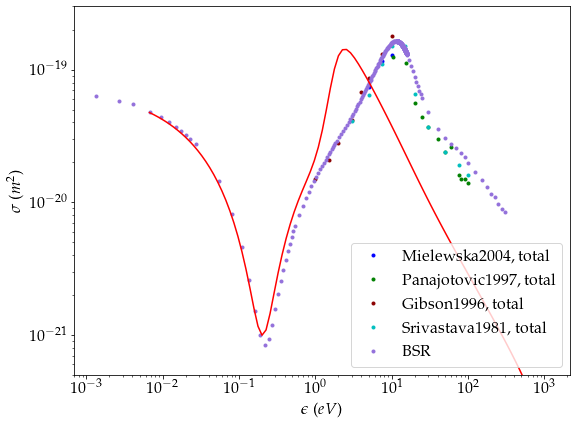

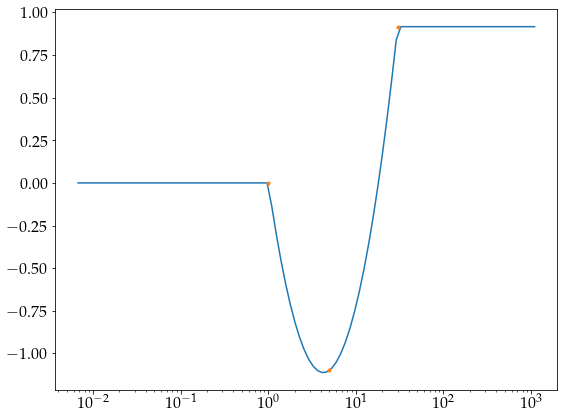

In [99]:
import scipy.interpolate as interpolate

def Elastic_model(theta,E_input,N=10):
    NE = len(E_input)
    E = np.copy(E_input)
    
    A, D, F, E1, t1, t2, t3 = theta
    
#     xx = np.array([0., np.log(5.0), np.log(10.0)])
#     yy = np.array([0., -np.log(2.0), np.log(2.5)])
#     tt, cc, kk = interpolate.splrep(xx, yy, s=0, k=2)
#     spline = interpolate.BSpline(tt, cc, kk, extrapolate=True)
#     emp_factor = np.zeros((NE,))
#     mask = (E<1.0)
#     emp_factor[mask] = 0.0
#     mask = (E>10.0)
#     emp_factor[mask] = spline(np.log(10.0))
#     mask = ( (E>=1.0) & (E<=10.0) )
#     emp_factor[mask] = spline(np.log(E[mask]))
#     tmp = ( E / t1 ) ** t2
#     kk = t3
#     E *= 0.5 * (1.0 + kk) - 0.5 * (1.0 - kk) * ( tmp - 1.0 ) / ( tmp + 1.0 )
    E *= 0.5*(1.+t1) - 0.5 * (1. - t1) * np.tanh( (E - t2) / t3 )
    
    k = np.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
    crs = np.zeros((NE,))

#     A, D, F, E1 = theta
    eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
    eta0 = np.arctan(eta0 * k)

    eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
    eta1 = np.arctan(eta1 * k)

    crs += np.sin(eta0 - eta1)**2

    for L in range(1,N):
        eta0 = np.copy(eta1)
        L1 = L+1
        eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
        eta1 = np.arctan(eta1 * k)
        
        crs += (L + 1.) * np.sin(eta0 - eta1)**2

    return crs * 4. * np.pi / k / k * a0 * a0

xtest = np.linspace(-5,7,100)
Etest = np.exp(xtest)
logModel1 = np.log( Elastic_model([-1.488, 65.4, -84.3, 0.983, 2.5, 1.5,1.0],Etest) )
    
plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,np.exp(logModel1),'-r')
plt.xscale('log')
plt.yscale('log')
plt.ylim([5e-22, 3e-19])
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.no-empirical.pdf", dpi=1200)

# plt.figure(1)
# plt.plot(Etest-E_ext[level-1],np.exp( - 1.0 / (1.0 + Etest/E_ext[level-1]) ),'-r')
# plt.xscale('log')
# plt.yscale('log')
# # plt.ylim([1e-23, 1e-20])
# plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
# plt.tight_layout()
# # plt.legend()
# fig = plt.gcf()
# fig.set_size_inches(9, 7)
# plt.show()

xx = np.array([0., np.log(5.0), np.log(30.0)])
yy = np.array([0., -np.log(3.0), np.log(2.5)])
tt, cc, kk = interpolate.splrep(xx, yy, s=0, k=2)
spline = interpolate.BSpline(tt, cc, kk, extrapolate=True)
emp_factor = np.zeros((100,))
mask = (Etest<1.0)
emp_factor[mask] = 0.0
mask = (Etest>30.0)
emp_factor[mask] = spline(np.log(30.0))
mask = ( (Etest>=1.0) & (Etest<=30.0) )
emp_factor[mask] = spline(np.log(Etest[mask]))

plt.figure(2)
plt.plot(Etest,emp_factor,'-')
plt.plot(np.exp(xx),yy,'.')
plt.xscale('log')
fig = plt.gcf()
fig.set_size_inches(9, 7)

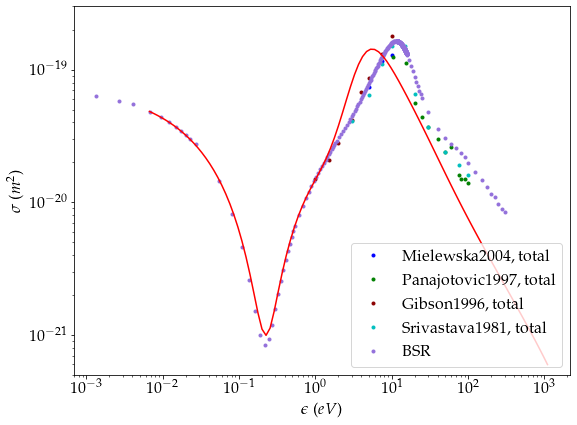

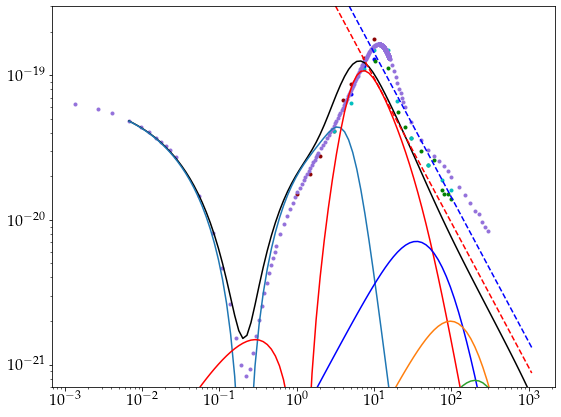

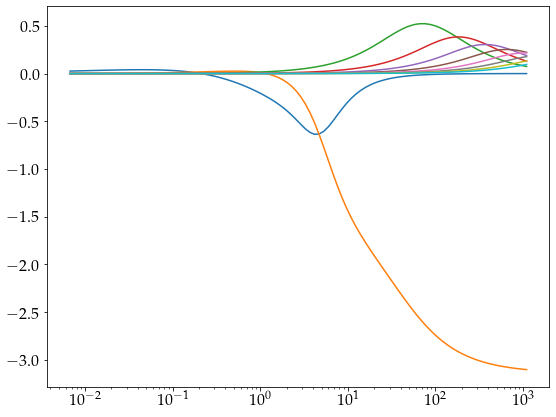

In [69]:
import scipy.interpolate as interpolate

def Elastic_model(theta,E_input,N=10):
    NE = len(E_input)
    E = np.copy(E_input)
    
    A, D, F, E1, t1, t2 = theta
    
    k = np.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
    crs = np.zeros((NE,))

#     A, D, F, E1 = theta
    eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
    eta0 = np.arctan(eta0 * k)

    eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
    eta1 = np.arctan(eta1 * k)

    crs += np.sin(eta0 - eta1)**2

    for L in range(1,N):
        eta0 = np.copy(eta1)
        L1 = L+1
        eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
        eta1 = np.arctan(eta1 * k)
        
        if (L==1):
            crs += t1 * (L + 1.) * np.sin(eta0 - eta1)**2            
        else:
            crs += (L + 1.) * np.sin(eta0 - eta1)**2

    return crs * 4. * np.pi / k / k * a0 * a0

xtest = np.linspace(-5,7,100)
Etest = np.exp(xtest)
theta_ref = [-1.488, 65.4, -84.3, 0.983, 1.0]
logModel1 = np.log( Elastic_model(theta_ref,Etest) )
    
plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,np.exp(logModel1),'-r')
plt.xscale('log')
plt.yscale('log')
plt.ylim([5e-22, 3e-19])
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.no-empirical.pdf", dpi=1200)

NE = len(Etest)
Nk = 10
E = np.copy(Etest)

theta_ref = [-1.488, 65.4, -84.3, 1.583, 1.0]
A, D, F, E1, t1 = theta_ref

k = np.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
crs = np.zeros((NE,))
crsk = np.zeros([NE,Nk])
detak = np.zeros([NE,Nk])

#     A, D, F, E1 = theta
eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
eta0 = np.arctan(eta0 * k)

eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
# eta1 -= 2.5 * k ** 3
eta1 = np.arctan(eta1 * k)

detak[:,0] = eta0 - eta1
crsk[:,0] = np.sin(eta0 - eta1)**2
crs += crsk[:,0]

for L in range(1,Nk):
    eta0 = np.copy(eta1)
    L1 = L+1
    eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
#     if(L==2): eta1 += 0.5 * k ** 3
    eta1 = np.arctan(eta1 * k)
    detak[:,L] = eta0 - eta1

    if (L==2):
        crsk[:,L] = t1 * (L + 1.) * np.sin(detak[:,L])**2
        crs += crsk[:,L]
    else:
        crsk[:,L] = (L + 1.) * np.sin(detak[:,L])**2
        crs += crsk[:,L]

crs *= 4. * np.pi / k / k * a0 * a0
for kk in range(Nk):
    crsk[:,kk] *= 4. * np.pi / k / k * a0 * a0

plt.figure(2)
for kk, Wk in enumerate(W):
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[kk],label=targetrefs[kk])
plt.plot(Etest,crs,'-k')
for kk in range(Nk):
    if(kk==1):
        plt.plot(Etest,crsk[:,kk],'-r')
        plt.plot(Etest,4.*np.pi/k/k*a0*a0*(kk+1.),'--r')
    elif(kk==2):
        plt.plot(Etest,crsk[:,kk],'-b')
        plt.plot(Etest,4.*np.pi/k/k*a0*a0*(kk+1.),'--b')
    else:
        plt.plot(Etest,crsk[:,kk],'-')
plt.xscale('log')
plt.yscale('log')
plt.ylim([7e-22, 3e-19])
fig = plt.gcf()
fig.set_size_inches(9, 7)

plt.figure(3)
for kk in range(Nk):
    plt.plot(Etest,detak[:,kk],'-')
plt.xscale('log')
fig = plt.gcf()
fig.set_size_inches(9, 7)

In [6]:
import torch
from models import *

targetW = torch.tensor(W[4])

class MERT(torch.nn.Module):
    def __init__(self, theta):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        A, D, F, E1, t1, t2, t3 = theta
        self.A = torch.nn.Parameter(torch.tensor(A))
        self.D = torch.nn.Parameter(torch.tensor(D))
        self.F = torch.nn.Parameter(torch.tensor(F))
        self.E1 = torch.nn.Parameter(torch.tensor(E1))
        self.t1 = torch.nn.Parameter(torch.tensor(t1))
        self.t2 = torch.nn.Parameter(torch.tensor(t2))
        self.t3 = torch.nn.Parameter(torch.tensor(t3))
        self.N = 10

    def forward(self):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        
        E = torch.clone(targetW[:,0])
        E *= 0.5*(1.+self.t1) - 0.5 * (1. - self.t1) * torch.tanh( (E - self.t2) / self.t3 )
#         E = targetW[:,0] * ( 0.5*(1.+self.t1) - 0.5 * (1. - self.t1) * torch.tanh( targetW[:,0] / self.t2 - 1.0 ) ) * torch.exp( (targetW[:,0] / self.t2)**self.t3 )
#         E = targetW[:,0] * ( 1.0 + self.t3*(targetW[:,0]/self.t2 - 1.0) / (1.0 + torch.exp(-self.t1*(targetW[:,0]/self.t2 - 1.0))) )
#         emp_factor = ( 1.0 + E / self.t2 ) ** self.t3
        NE = len(E)

        k = torch.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
        crs = torch.zeros((NE,))

    #     A, D, F, E1 = theta
        eta0 = - self.A * ( 1. + 4. / 3. * alpha * k * k * torch.log(k) ) - np.pi / 3. * alpha * k + self.D * k**2 + self.F * k**3
        eta0 = torch.arctan(eta0 * k)

        eta1 = np.pi / 15. * alpha * k * ( 1. - torch.sqrt(E/self.E1) )
#         eta1 += self.t2 * k**3
        eta1 = torch.arctan(eta1 * k)

        crs += torch.sin(eta0 - eta1)**2

        for L in range(1,self.N):
            eta0 = torch.clone(eta1)
            L1 = L+1
            eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
#             if(L==2):
#                 eta1 += self.t1 * k**3
#             elif(L==2):
#                 eta1 += self.t2 * k**3
#             elif(L==3):
#                 eta1 += self.t3 * k**3
            eta1 = torch.arctan(eta1 * k)

            crs += (L + 1.) * torch.sin(eta0 - eta1)**2

        crs *= 4. * np.pi / k / k * a0 * a0
        
        return crs
#         return torch.sum( (torch.log(crs) - torch.log(targetW[:,1]))**2 )

# [-1.44, 54.97, -69.50, 0.70, 0.43, 0.43, 0.68
theta_ref = [-1.488, 65.4, -84.3, 1.583, 0.5, 0.5, 0.5]
model = MERT(theta_ref)

optimizer = torch.optim.LBFGS(model.parameters(),lr=1e-3)
    
def closure():
    crs_model = model.forward()
    lk = torch.sum( (torch.log(crs_model) - torch.log(targetW[:,1]))**2 )
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
    crs_model = model.forward()
    lk = torch.sum( (torch.log(crs_model) - torch.log(targetW[:,1]))**2 )
    if t % 100 == 99:
        print(t, lk.item())

    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
theta_opt = []
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)
        theta_opt += [float(param.data)]
print(theta_opt)

99 3.1360736747204894
199 2.768796789635241
299 2.760969382511103
399 2.760415056953498
499 2.760390801821716
599 2.7603897737758487
699 2.760386894046091
799 2.7603979313758273
899 2.7604172803210902
999 2.760446596726372
A tensor(-1.4175)
D tensor(62.5779)
F tensor(-85.2362)
E1 tensor(0.7364)
t1 tensor(0.4463)
t2 tensor(1.6514)
t3 tensor(1.9992)
[-1.4174809455871582, 62.577884674072266, -85.23619079589844, 0.7364063858985901, 0.44634780287742615, 1.651408314704895, 1.9992294311523438]


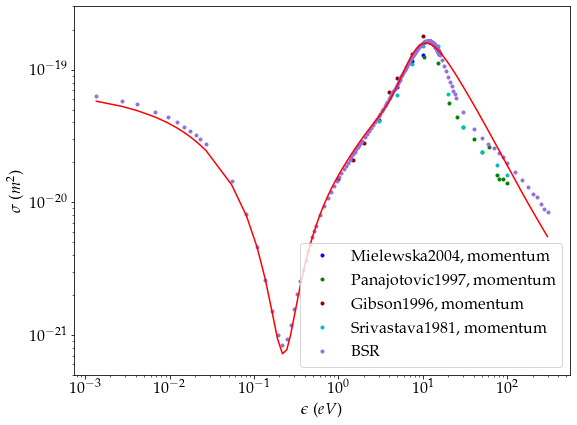

In [9]:
# model.t3 = torch.nn.Parameter(torch.tensor(-0.05))
model1 = model.forward().detach().numpy()

temp = np.array([targetW[:,0].detach().numpy(), model1]).T
filename = 'Elastic.MERT_shifted.txt'
np.savetxt(filename, temp)
    
plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(targetW[:,0].detach().numpy(),model1,'-r')
plt.xscale('log')
plt.yscale('log')
plt.ylim([5e-22, 3e-19])
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()

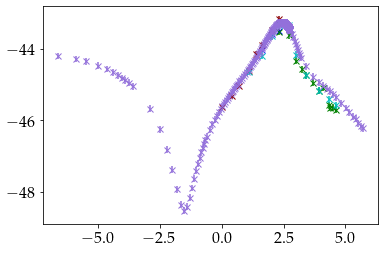

In [5]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [8]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    lp = 0.0
#     if ((theta[5]<=0.1) or (theta[5]>10.0) or (theta[4]<=0.0) or (theta[4]>=1.0) or (theta[6]<=1.0e-2) or (theta[6]>10.0)):
#         return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([-1.488, 65.4, -84.3, 0.983])
    sigma2 = ( 0.5 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:4] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
#     lp += - np.log(theta[5]) - np.log(np.log(1e1) - np.log(0.1e0))
#     lp += - np.log(theta[6]) - np.log(np.log(1e1) - np.log(1e-2))
#     lp += - np.log(theta[5]) - np.log(np.log(5.0) - np.log(0.2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( elastic_shifted_MERT(theta[:7],W[k][:,0]) )
#         logModel = np.log( elastic_MERT(theta[:4],W[k][:,0]) )
#         print(len(W[k][:,0]), logModel.shape)
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [9]:
import emcee
nwalkers = 32
theta_ref = np.array([-1.488, 65.4, -84.3, 0.983, 1.0, 0.1])
# theta_ref = np.array([-1.488, 65.4, -84.3, 0.983, 2.5, 1.5, 0.5, 1.0, 0.1])
# theta_ref = np.array([-1.44, 54.97, -69.50, 0.70, 0.43, 0.43, 0.68, 1.0, 0.1])
# theta_ref = np.array([-1.42, 57.73, -77.36, 0.73, 0.44, 0.51, 1.0, 0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
)

In [10]:
sampler.run_mcmc(pos, 1);

for k in range(30):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  7%|███▌                                                | 34/500 [00:00<00:02, 158.10it/s]/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:94: RuntimeWarning: invalid value encountered in sqrt
  eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
100%|███████████████████████████████████████████████████| 500/500 [00:04<00:00, 115.40it/s]


[37.78784296 36.3990994  35.55674551 41.37729569 38.22914423 62.90649647]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 90.08it/s]


[ 57.94347722  55.95285305  54.86739145  59.8980164   44.14950486
 128.06841815]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 92.43it/s]


...

[160.62475631 148.46864534 156.5805855  226.72709767 210.54858668
 257.47047108]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 88.07it/s]


[160.08023435 147.15892378 155.21992795 224.08589035 212.51154075
 258.24366167]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 91.40it/s]


[159.13336974 146.6143343  154.34514186 223.9607049  211.86261842
 259.13713314]


(5954, 6)


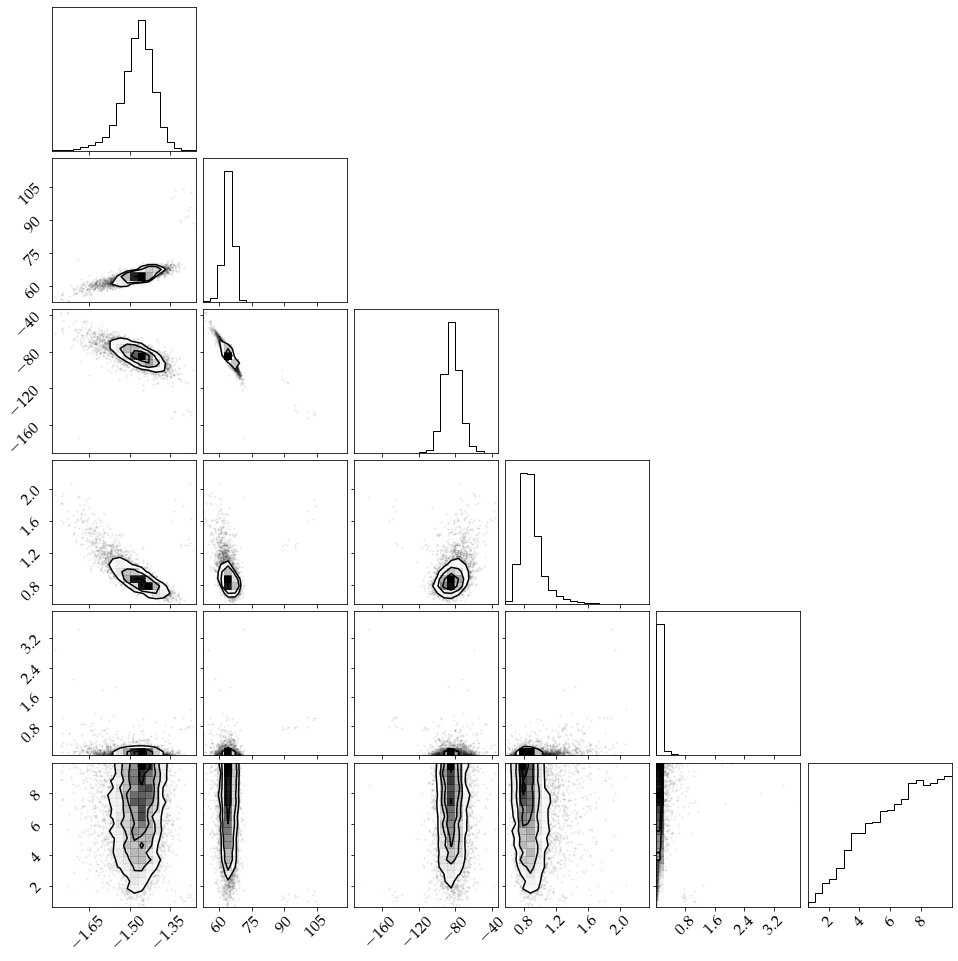

In [15]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
mask = flat_samples[:,0]<-1.25
flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);

# tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.elastic.7param.dat')
# fig.savefig("./elastic.corner.pdf", dpi=600)

6.456778969569396e-20


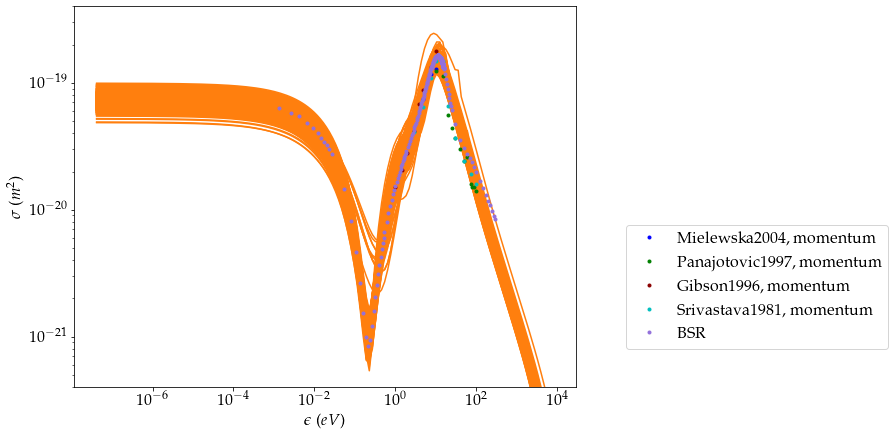

In [6]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.elastic.7param.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/9), 9])

Nw = 150
wtest = np.linspace(-17,9.,Nw)
Etest = np.exp(wtest)

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = elastic_shifted_MERT(sample[:7],Etest)
#     models = elastic_MERT(sample[:4],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask], models[mask], "C1", alpha=1)
print(models[0])
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')

# fig.savefig("./elastic.curve.1.pdf", dpi=1200)

# for k, lxcat in enumerate(datasets[:-2]):
#     filename = './crs/%s.txt' % lxcat
#     tmp = cross.multipleCrossSections(filename)
#     for c in tmp.crs:
#         if ((c.colType==0)):
#             plt.plot(c.data[:,0], c.data[:,1],'-',label=lxcat)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([4e-22, 4e-19])
# plt.xlim([1e-3, 1e3])
plt.legend(loc=(1.1,0.1))
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./elastic.curve.with-lxcats.pdf", dpi=1200)